In [72]:
import cv2
import random
import numpy as np
from pathlib import Path
import einops
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers

In [73]:
!ls input/surf-dataset-05/surf_dataset_05

test  train  val


In [74]:
def format_frames(frame, output_size):
  """
    Pad and resize an image from a video.

    Args:
      frame: Image that needs to resized and padded.
      output_size: Pixel size of the output frame image.

    Return:
      Formatted frame with padding of specified output size.
  """
  frame = tf.image.convert_image_dtype(frame, tf.float32)
  frame = tf.image.resize_with_pad(frame, *output_size)
  return frame

def frames_from_video_file(video_path, n_frames, output_size = (224,224), frame_step = 15):
  """
    Creates frames from each video file present for each category.

    Args:
      video_path: File path to the video.
      n_frames: Number of frames to be created per video file.
      output_size: Pixel size of the output frame image.

    Return:
      An NumPy array of frames in the shape of (n_frames, height, width, channels).
  """
  # Read each video frame by frame
  result = []
  src = cv2.VideoCapture(str(video_path))

  video_length = src.get(cv2.CAP_PROP_FRAME_COUNT)

  need_length = 1 + (n_frames - 1) * frame_step

  if need_length > video_length:
    start = 0
  else:
    max_start = video_length - need_length
    start = random.randint(0, max_start + 1)

  src.set(cv2.CAP_PROP_POS_FRAMES, start)
  # ret is a boolean indicating whether read was successful, frame is the image itself
  ret, frame = src.read()
  result.append(format_frames(frame, output_size))

  for _ in range(n_frames - 1):
    for _ in range(frame_step):
      ret, frame = src.read()
    if ret:
      frame = format_frames(frame, output_size)
      result.append(frame)
    else:
      result.append(np.zeros_like(result[0]))
  src.release()
  result = np.array(result)[..., [2, 1, 0]]

  return result

class FrameGenerator:
  def __init__(self, path, n_frames, training = False):
    """ Returns a set of frames with their associated label.

      Args:
        path: Video file paths.
        n_frames: Number of frames.
        training: Boolean to determine if training dataset is being created.
    """
    self.path = path
    self.n_frames = n_frames
    self.training = training
    self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
    self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

  def get_files_and_class_names(self):
    video_paths = list(self.path.glob('*/*.avi'))
    classes = [p.parent.name for p in video_paths]
    return video_paths, classes

  def __call__(self):
    video_paths, classes = self.get_files_and_class_names()

    pairs = list(zip(video_paths, classes))

    if self.training:
      random.shuffle(pairs)

    for path, name in pairs:
      video_frames = frames_from_video_file(path, self.n_frames)
      label = self.class_ids_for_name[name] # Encode labels
      yield video_frames, label

In [75]:
n_frames = 10
batch_size = 8

train_dir = Path('input/surf-dataset-05/surf_dataset_05/train')
val_dir = Path('input/surf-dataset-05/surf_dataset_05/val')
test_dir = Path('input/surf-dataset-05/surf_dataset_05/test')

output_signature = (tf.TensorSpec(shape = (None, None, None, 3), dtype = tf.float32),
                    tf.TensorSpec(shape = (), dtype = tf.int16))

train_ds = tf.data.Dataset.from_generator(FrameGenerator(train_dir, n_frames, training=True),
                                          output_signature = output_signature)


# Batch the data
train_ds = train_ds.batch(batch_size)

val_ds = tf.data.Dataset.from_generator(FrameGenerator(val_dir, n_frames),
                                        output_signature = output_signature)
val_ds = val_ds.batch(batch_size)

test_ds = tf.data.Dataset.from_generator(FrameGenerator(test_dir, n_frames),
                                         output_signature= output_signature)
test_ds = test_ds.batch(batch_size)

In [76]:
# Check one batch from val_ds
for frames, labels in test_ds.take(1):
    print("Frames shape:", frames.shape)  # Should be (batch_size, n_frames, H, W, 3)
    print("Frames dtype:", frames.dtype)  # Should be tf.float32
    print("Labels shape:", labels.shape)  # Should be (batch_size,)
    print("Labels dtype:", labels.dtype)  # Should be tf.int16


Frames shape: (8, 10, 224, 224, 3)
Frames dtype: <dtype: 'float32'>
Labels shape: (8,)
Labels dtype: <dtype: 'int16'>


In [77]:
# Define the dimensions of one frame in the set of frames created
HEIGHT = 224
WIDTH = 224

In [78]:
@tf.keras.utils.register_keras_serializable()
class Conv2Plus1D(keras.layers.Layer):
  def __init__(self, filters, kernel_size, padding, **kwargs):
    """
      A sequence of convolutional layers that first apply the convolution operation over the
      spatial dimensions, and then the temporal dimension.
    """
    super().__init__()
    self.seq = keras.Sequential([
        # Spatial decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(1, kernel_size[1], kernel_size[2]),
                      padding=padding),
        # Temporal decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(kernel_size[0], 1, 1),
                      padding=padding)
        ])

  def call(self, x):
    return self.seq(x)
  
  def get_config(self):
    config = super().get_config()
    config.update({"filters": self.filters,
                   "kernel_size": self.kernel_size,
                   "padding": self.padding})
    return config 

In [79]:
@tf.keras.utils.register_keras_serializable()
class ResidualMain(keras.layers.Layer):
  """
    Residual block of the model with convolution, layer normalization, and the
    activation function, ReLU.
  """
  def __init__(self, filters, kernel_size):
    super().__init__()
    self.seq = keras.Sequential([
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization(),
        layers.ReLU(),
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

  def get_config(self):
    config = super().get_config()
    config.update({"filters": self.filters,
                   "kernel_size": self.kernel_size})
    return config 

In [80]:
@tf.keras.utils.register_keras_serializable()
class Project(keras.layers.Layer):
  """
    Project certain dimensions of the tensor as the data is passed through different
    sized filters and downsampled.
  """
  def __init__(self, units):
    super().__init__()
    self.seq = keras.Sequential([
        layers.Dense(units),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

  def get_config(self):
    config = super().get_config()
    config.update({"units": self.units})
    return config


In [81]:
def add_residual_block(input, filters, kernel_size):
  """
    Add residual blocks to the model. If the last dimensions of the input data
    and filter size does not match, project it such that last dimension matches.
  """
  out = ResidualMain(filters,
                     kernel_size)(input)

  res = input
  # Using the Keras functional APIs, project the last dimension of the tensor to
  # match the new filter size
  if out.shape[-1] != input.shape[-1]:
    res = Project(out.shape[-1])(res)

  return layers.add([res, out])


In [82]:
@tf.keras.utils.register_keras_serializable()
class ResizeVideo(keras.layers.Layer):
  def __init__(self, height, width):
    super().__init__()
    self.height = height
    self.width = width
    self.resizing_layer = layers.Resizing(self.height, self.width)

  def call(self, video):
    """
      Use the einops library to resize the tensor.

      Args:
        video: Tensor representation of the video, in the form of a set of frames.

      Return:
        A downsampled size of the video according to the new height and width it should be resized to.
    """
    # b stands for batch size, t stands for time, h stands for height,
    # w stands for width, and c stands for the number of channels.
    old_shape = einops.parse_shape(video, 'b t h w c')
    images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
    images = self.resizing_layer(images)
    videos = einops.rearrange(
        images, '(b t) h w c -> b t h w c',
        t = old_shape['t'])
    return videos
      
  def get_config(self):
    config = super().get_config()
    config.update({"height": self.height,
                   "width": self.width})
    return config 

In [83]:
input_shape = (None, 10, HEIGHT, WIDTH, 3)
input = layers.Input(shape=(input_shape[1:]))
x = input

x = Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = ResizeVideo(HEIGHT // 2, WIDTH // 2)(x)

# Block 1
x = add_residual_block(x, 16, (3, 3, 3))
x = ResizeVideo(HEIGHT // 4, WIDTH // 4)(x)

# Block 2
x = add_residual_block(x, 32, (3, 3, 3))
x = ResizeVideo(HEIGHT // 8, WIDTH // 8)(x)

# Block 3
x = add_residual_block(x, 64, (3, 3, 3))
x = ResizeVideo(HEIGHT // 16, WIDTH // 16)(x)

# Block 4
x = add_residual_block(x, 128, (3, 3, 3))

x = layers.GlobalAveragePooling3D()(x)
x = layers.Flatten()(x)
x = layers.Dense(10)(x)

model = keras.Model(input, x)


In [84]:
checkpoint_filepath = Path('kaggle/working/checkpoints.weights.h5')

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True, # Saves only the weights, not the entire model (smaller files)
    monitor='accuracy',     # Monitor validation loss
    mode='min',             # Save when val_loss is at its minimum
    save_best_only=False,   # Set to True to save ONLY the best model weights
                            # Set to False to save weights at each 'save_freq'
    save_freq='epoch',      # Save at the end of every epoch
    verbose=1               # Print messages when saving
)

In [85]:
model.compile(loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = keras.optimizers.Adam(learning_rate = 0.0001),
              metrics = ['accuracy'])


In [86]:
history = model.fit(x = train_ds,
                    epochs = 50,
                    validation_data = val_ds,
                    callbacks=[model_checkpoint_callback])


Epoch 1/50


I0000 00:00:1753104638.108528      97 service.cc:148] XLA service 0x780b9c002b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753104638.109515      97 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753104640.560749      97 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1753104642.178005      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753104642.378263      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1753104656.355018      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     47/Unknown 196s 3s/step - accuracy: 0.5469 - loss: 1.0210

E0000 00:00:1753104818.630049      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753104818.821106      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


     48/Unknown 211s 4s/step - accuracy: 0.5485 - loss: 1.0149

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
E0000 00:00:1753104859.477682      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753104859.658321      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: saving model to kaggle/working/checkpoints.weights.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - accuracy: 0.5501 - loss: 1.0091 - val_accuracy: 0.6712 - val_loss: 0.6928
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6828 - loss: 0.5887
Epoch 2: saving model to kaggle/working/checkpoints.weights.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.6833 - loss: 0.5885 - val_accuracy: 0.5479 - val_loss: 0.8928
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7037 - loss: 0.6013
Epoch 3: saving model to kaggle/working/checkpoints.weights.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.7039 - loss: 0.6014 - val_accuracy: 0.6712 - val_loss: 0.6619
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6816 - loss: 0.7166
Epoch 4: saving model to kaggle/working/checkpoints.weights.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.6829 - loss: 0.7134 - val_accuracy: 0.5479 - val_loss: 0.8472
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━

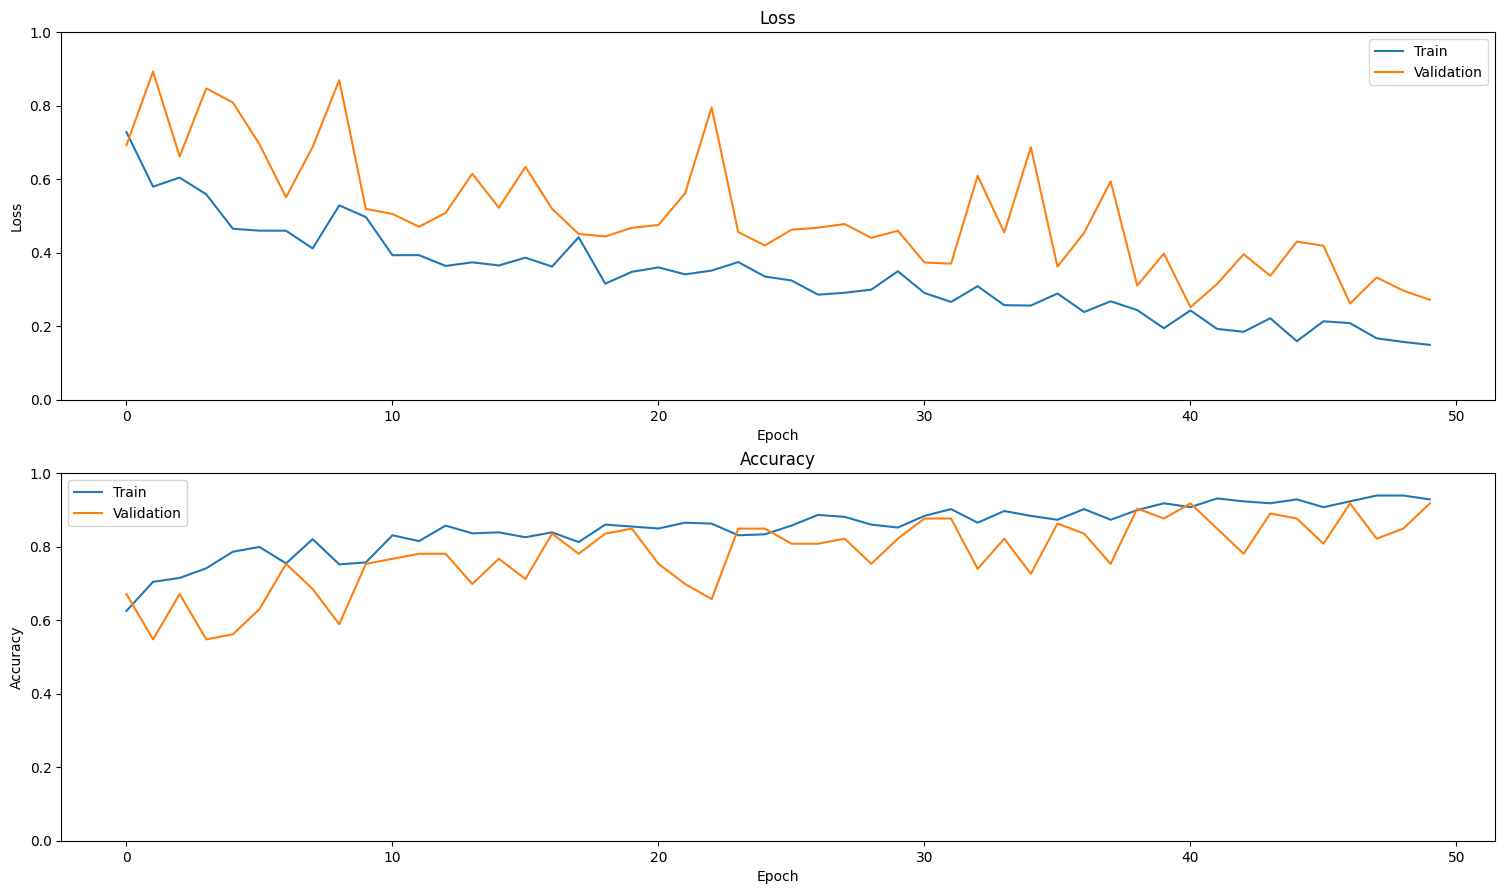

In [87]:
def plot_history(history):
  """
    Plotting training and validation learning curves.

    Args:
      history: model history with all the metric measures
  """
  fig, (ax1, ax2) = plt.subplots(2)

  fig.set_size_inches(18.5, 10.5)

  # Plot loss
  ax1.set_title('Loss')
  ax1.plot(history.history['loss'], label = 'train')
  ax1.plot(history.history['val_loss'], label = 'test')
  ax1.set_ylabel('Loss')

  # Determine upper bound of y-axis
  max_loss = max(history.history['loss'] + history.history['val_loss'])

  ax1.set_ylim([0, np.ceil(max_loss)])
  ax1.set_xlabel('Epoch')
  ax1.legend(['Train', 'Validation'])

  # Plot accuracy
  ax2.set_title('Accuracy')
  ax2.plot(history.history['accuracy'],  label = 'train')
  ax2.plot(history.history['val_accuracy'], label = 'test')
  ax2.set_ylabel('Accuracy')
  ax2.set_ylim([0, 1])
  ax2.set_xlabel('Epoch')
  ax2.legend(['Train', 'Validation'])

  plt.show()

plot_history(history)


In [88]:
model.evaluate(test_ds, return_dict=True)

      8/Unknown 25s 3s/step - accuracy: 0.9470 - loss: 0.2260

E0000 00:00:1753113382.724213      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753113382.917241      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9257 - loss: 0.2681


{'accuracy': 0.8405796885490417, 'loss': 0.4367463290691376}

In [89]:
def get_actual_predicted_labels(dataset):
  """
    Create a list of actual ground truth values and the predictions from the model.

    Args:
      dataset: An iterable data structure, such as a TensorFlow Dataset, with features and labels.

    Return:
      Ground truth and predicted values for a particular dataset.
  """
  actual = [labels for _, labels in dataset.unbatch()]
  predicted = model.predict(dataset)

  actual = tf.stack(actual, axis=0)
  predicted = tf.concat(predicted, axis=0)
  predicted = tf.argmax(predicted, axis=1)

  return actual, predicted


In [90]:
def plot_confusion_matrix(actual, predicted, labels, ds_type):
  cm = tf.math.confusion_matrix(actual, predicted)
  ax = sns.heatmap(cm, annot=True, fmt='g')
  sns.set(rc={'figure.figsize':(12, 12)})
  sns.set(font_scale=1.4)
  ax.set_title('Confusion matrix of action recognition for ' + ds_type)
  ax.set_xlabel('Predicted Action')
  ax.set_ylabel('Actual Action')
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(labels)
  ax.yaxis.set_ticklabels(labels)


In [91]:
fg = FrameGenerator(train_dir, n_frames, training=True)
labels = list(fg.class_ids_for_name.keys())


48/48 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step


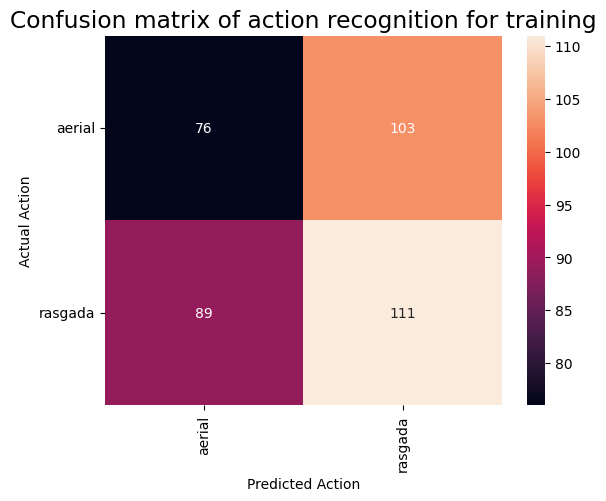

In [92]:
actual, predicted = get_actual_predicted_labels(train_ds)
plot_confusion_matrix(actual, predicted, labels, 'training')


9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


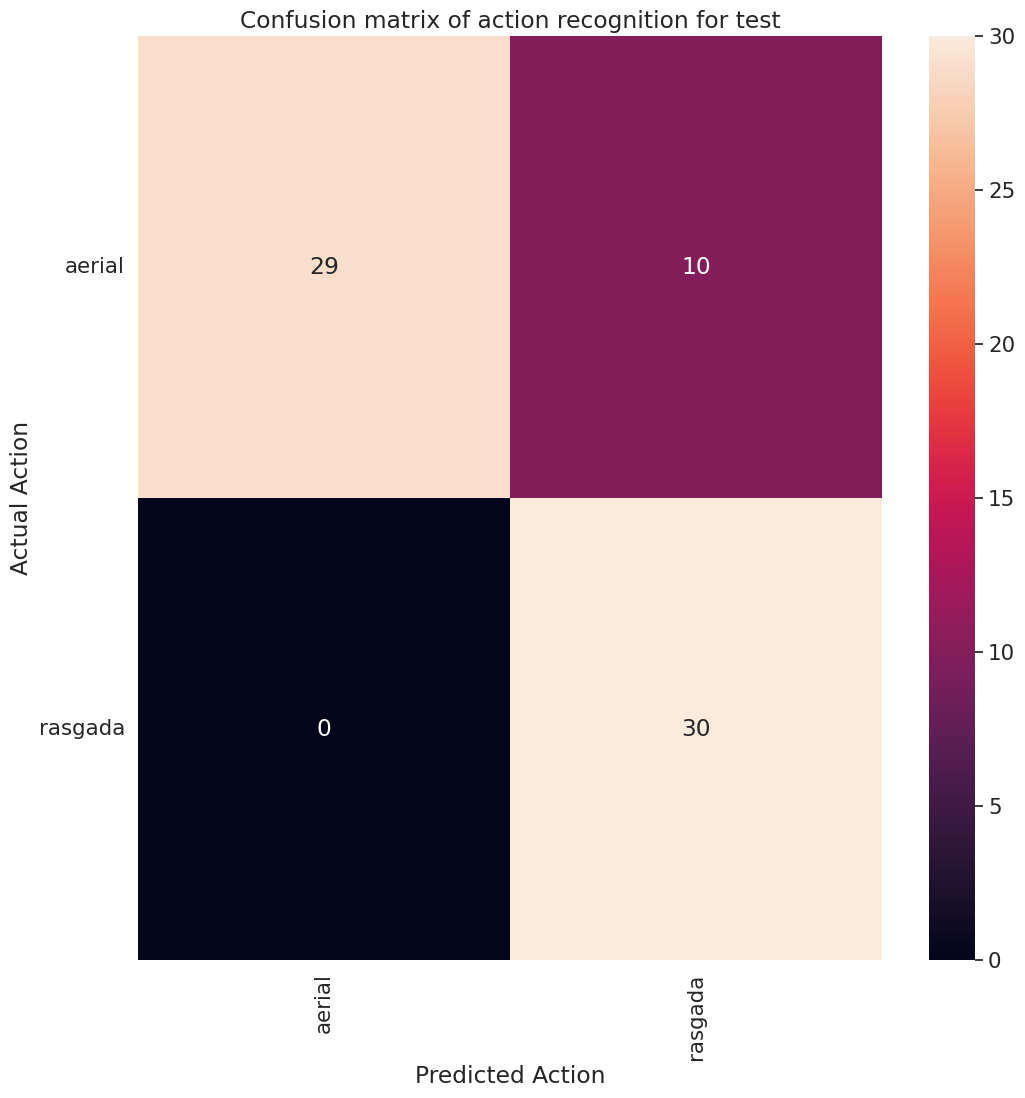

In [93]:
actual, predicted = get_actual_predicted_labels(test_ds)
plot_confusion_matrix(actual, predicted, labels, 'test')


In [94]:
model.save('working/classificador_final.keras')

AttributeError: 'Conv2Plus1D' object has no attribute 'filters'